In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, balanced_accuracy_score, f1_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Kaggle dataset setup

Download `kmader/skin-cancer-mnist-ham10000` with `kagglehub`, reads `HAM10000_metadata.csv`, and maps each `image_id` to the corresponding JPG in the two image folders.

In [2]:
# Download the dataset from Kaggle

DATASET = "kmader/skin-cancer-mnist-ham10000"
data_dir = Path(kagglehub.dataset_download(DATASET))

print("Dataset directory:", data_dir)
print("Top-level files/folders:")
for path in sorted(data_dir.iterdir()):
    print(" -", path.name)
    
images_part_1_dir = data_dir / "HAM10000_images_part_1"
images_part_2_dir = data_dir / "HAM10000_images_part_2"

print("Number of images in 'HAM10000_images_part_1':", len(list(images_part_1_dir.glob("*.jpg"))))
print("Number of images in 'HAM10000_images_part_2':", len(list(images_part_2_dir.glob("*.jpg"))))

Dataset directory: C:\Users\thanh\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Top-level files/folders:
 - HAM10000_images_part_1
 - HAM10000_images_part_2
 - HAM10000_metadata.csv
 - hmnist_28_28_L.csv
 - hmnist_28_28_RGB.csv
 - hmnist_8_8_L.csv
 - hmnist_8_8_RGB.csv
Number of images in 'HAM10000_images_part_1': 5000
Number of images in 'HAM10000_images_part_2': 5015


In [3]:
# Load metadata and map every image_id to its JPG file

metadata = list(data_dir.rglob("HAM10000_metadata.csv"))
if not metadata:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")

metadata_path = metadata[0]
df = pd.read_csv(metadata_path)

# Images are stored across HAM10000_images_part_1 and part_2
image_files = list(data_dir.rglob("*.jpg"))
image_path_by_id = {path.stem: str(path) for path in image_files}
df["image_path"] = df["image_id"].map(image_path_by_id)

missing_images = df["image_path"].isna().sum()
if missing_images:
    missing_ids = df.loc[df["image_path"].isna(), "image_id"].head(10).tolist()
    raise FileNotFoundError(
        f"Could not locate {missing_images} image files. Example missing IDs: {missing_ids}"
    )

print(df.head())
print("Metadata shape:", df.shape)
print("Images discovered:", len(image_path_by_id))


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
2  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
3  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
Metadata shape: (10015, 8)
Images discovered: 10015


## Prepare labels to split Train/Test sets

In [4]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Full dataset shape:", df.shape)
print("Unique lesions:", df["lesion_id"].nunique())

Classes: [(0, 'akiec'), (1, 'bcc'), (2, 'bkl'), (3, 'df'), (4, 'mel'), (5, 'nv'), (6, 'vasc')]
Full dataset shape: (10015, 9)
Unique lesions: 7470


In [5]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)\
    
df["fold"] = -1
for fold, (_, fold_indices) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["lesion_id"])
):
    df.loc[fold_indices, "fold"] = fold
    
df["fold"] = -1
for fold, (_, fold_indices) in enumerate(sgkf.split(df, y=df["label"], groups=df["lesion_id"])):
    df.loc[fold_indices, "fold"] = fold

test_fold = 0           # Choose first fold as test set
validation_fold = 1     # Choose second fold as validation set

train_df = df.loc[~ df["fold"].isin([test_fold, validation_fold])].copy()   # Copy Folds 2-9 for training
val_df = df.loc[df["fold"] == validation_fold].copy()
test_df = df.loc[df["fold"] == test_fold].copy()

for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    print(
        f"{split_name:10s}: {len(split_df):5d} images, "
        f"{split_df['lesion_id'].nunique():5d} lesions"
    )
    print(split_df["dx"].value_counts(normalize=True).sort_index().round(3))
    print()

# Leakage checks.
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)
assert len(train_df) + len(val_df) + len(test_df) == len(df)

print("No Leakage (no lesion_id appears in multiple splits).")

train     :  8011 images,  5975 lesions
dx
akiec    0.033
bcc      0.051
bkl      0.110
df       0.011
mel      0.111
nv       0.669
vasc     0.014
Name: proportion, dtype: float64

validation:  1002 images,   748 lesions
dx
akiec    0.033
bcc      0.052
bkl      0.110
df       0.011
mel      0.111
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

test      :  1002 images,   747 lesions
dx
akiec    0.032
bcc      0.051
bkl      0.110
df       0.012
mel      0.112
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

No Leakage (no lesion_id appears in multiple splits).


In [6]:
# Dataframe process for CNN model
IMAGE_SIZE = (32, 32)

def load_image_array(image_path, size=IMAGE_SIZE):
    """Load one local JPG as a normalized RGB NumPy array."""
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(size)
        return np.asarray(image, dtype=np.float32) / 255.0


def dataframe_to_arrays(split_df):
    """Convert one metadata split into image and integer-label arrays."""
    X = np.stack([load_image_array(path) for path in split_df["image_path"]])
    y = split_df["label"].to_numpy(dtype=np.int64)
    return X, y

X_train, y_train = dataframe_to_arrays(train_df)
X_val, y_val = dataframe_to_arrays(val_df)
X_test, y_test = dataframe_to_arrays(test_df)

print("Training set:  ", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:      ", X_test.shape, y_test.shape)
print("Pixel range:", float(X_train.min()), "to", float(X_train.max()))

Training set:   (8011, 32, 32, 3) (8011,)
Validation set: (1002, 32, 32, 3) (1002,)
Test set:       (1002, 32, 32, 3) (1002,)
Pixel range: 0.0 to 1.0


## EDA & Preprocessing

In [7]:
print(train_df.head())
train_df.shape

     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   
5  HAM_0001466  ISIC_0027850  bkl   histo  75.0  male          ear   
6  HAM_0002761  ISIC_0029176  bkl   histo  60.0  male         face   

                                          image_path  label  fold  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
5  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
6  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     2  


(8011, 10)

In [8]:
train_df.info()
train_df.describe().T
train_df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 8011 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     8011 non-null   object 
 1   image_id      8011 non-null   object 
 2   dx            8011 non-null   object 
 3   dx_type       8011 non-null   object 
 4   age           7961 non-null   float64
 5   sex           8011 non-null   object 
 6   localization  8011 non-null   object 
 7   image_path    8011 non-null   object 
 8   label         8011 non-null   int64  
 9   fold          8011 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 688.4+ KB


['lesion_id',
 'image_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization',
 'image_path',
 'label',
 'fold']

In [9]:
print("\nMissing values per column:")
display(train_df.isnull().sum())

print('\nDuplicate values per column:')
display(train_df.drop(columns=['image_path']).duplicated().sum())


Missing values per column:


lesion_id        0
image_id         0
dx               0
dx_type          0
age             50
sex              0
localization     0
image_path       0
label            0
fold             0
dtype: int64


Duplicate values per column:


np.int64(0)

In [10]:
print('\nFill missing values in \'age\' with the most common age:')
train_df['age'] = train_df['age'].fillna(train_df['age'].median())
display(train_df.isnull().sum())


Fill missing values in 'age' with the most common age:


lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
fold            0
dtype: int64

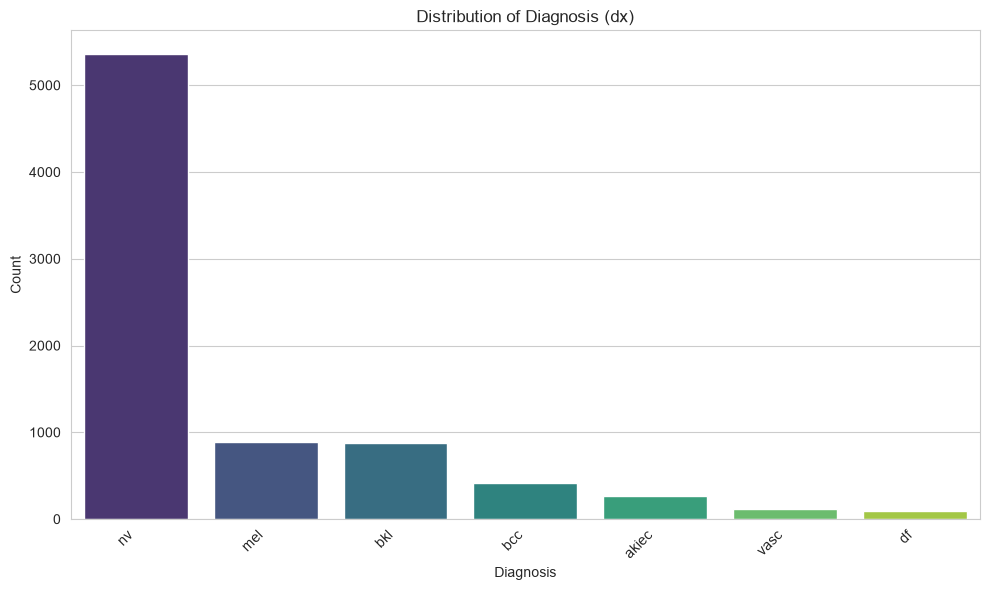

In [11]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='dx', order=train_df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

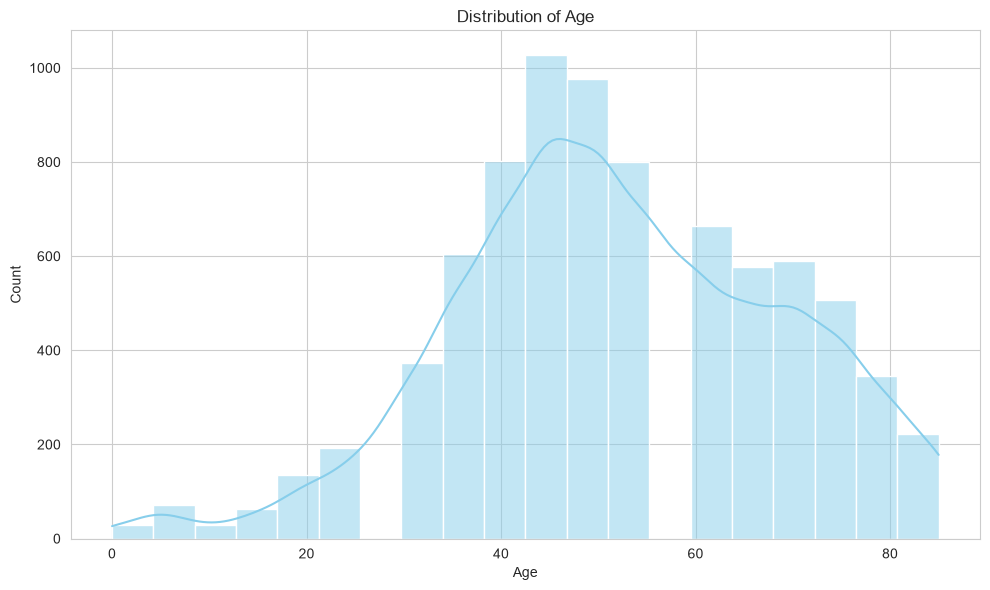

In [12]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

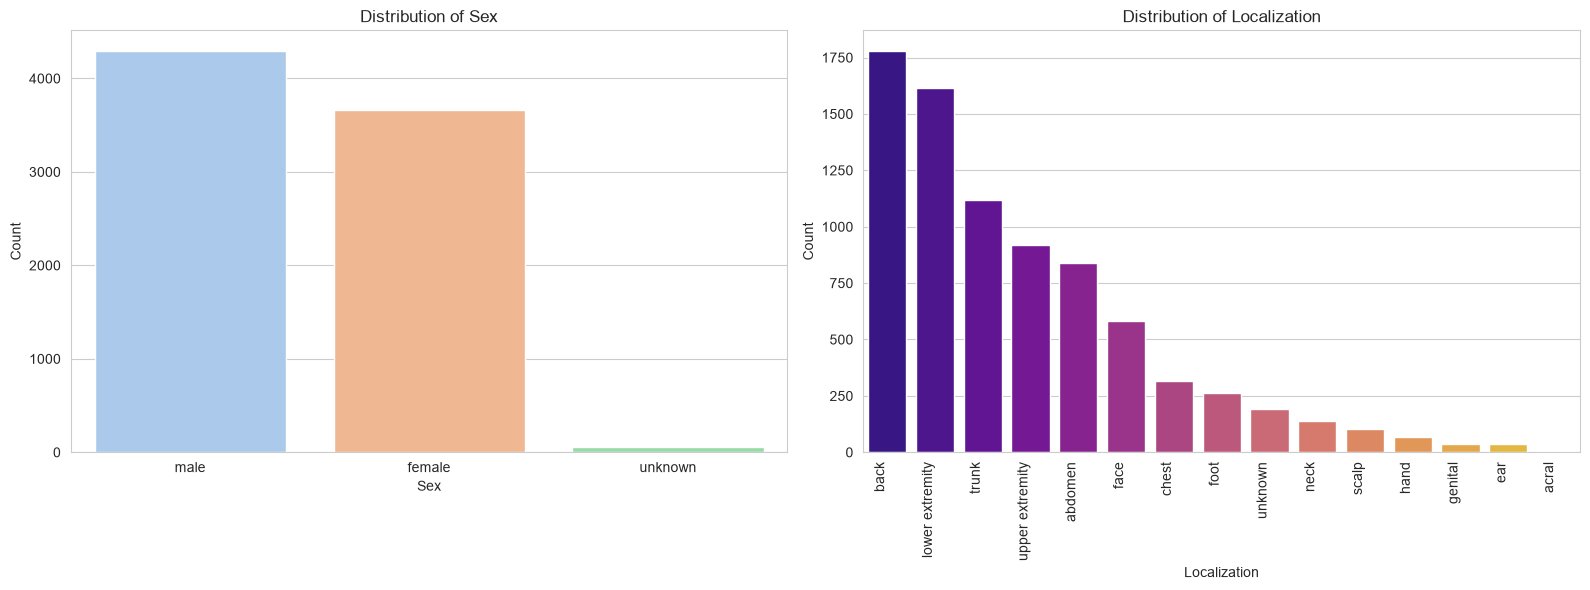

In [13]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train_df, x='sex', ax=axes[0], palette='pastel', order=train_df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=train_df, x='localization', ax=axes[1], palette='plasma', order=train_df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

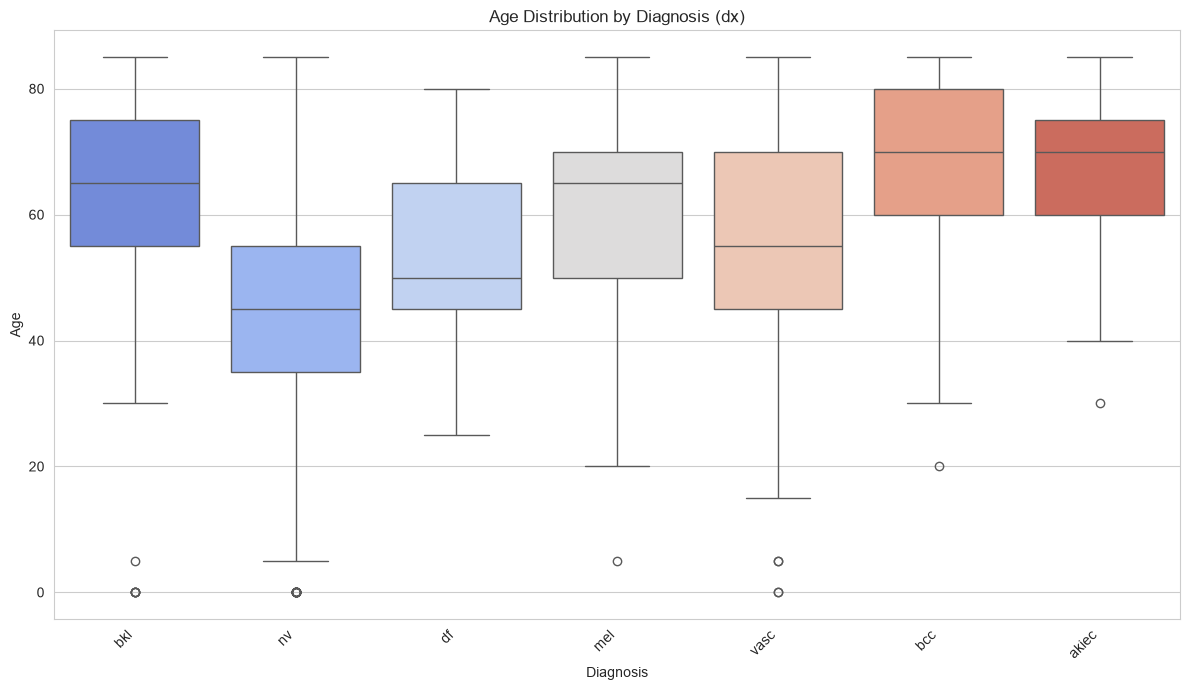

In [14]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=train_df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
# 5. Detect and handle image outliers
# Brightness and contrast limits are calculated from the **training set only** with the IQR rule. 
# Flagged training images are displayed and then removed before any model is trained. 
# The validation and test sets are not modified, which prevents test-data leakage.

train_brightness = X_train.mean(axis=(1, 2, 3))
train_contrast = X_train.std(axis=(1, 2, 3))

def iqr_outlier_mask(values):
    values = np.asarray(values)
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (values < lower) | (values > upper)
    return mask, lower, upper


brightness_outlier, brightness_lower, brightness_upper = iqr_outlier_mask(
    train_brightness
)
contrast_outlier, contrast_lower, contrast_upper = iqr_outlier_mask(
    train_contrast
)
train_outlier_mask = brightness_outlier | contrast_outlier

train_metadata_aligned = train_df.reset_index(drop=True)
train_quality_df = pd.DataFrame({
    "training_row": np.arange(len(X_train)),
    "image_id": train_metadata_aligned["image_id"],
    "lesion_id": train_metadata_aligned["lesion_id"],
    "dx": train_metadata_aligned["dx"],
    "brightness": train_brightness,
    "contrast": train_contrast,
    "brightness_outlier": brightness_outlier,
    "contrast_outlier": contrast_outlier,
    "potential_outlier": train_outlier_mask,
})

print("Training images checked:", len(train_quality_df))
print("Brightness limits:", round(brightness_lower, 4), "to", round(brightness_upper, 4))
print("Contrast limits:", round(contrast_lower, 4), "to", round(contrast_upper, 4))
print("Brightness outliers flagged:", int(brightness_outlier.sum()))
print("Contrast outliers flagged:", int(contrast_outlier.sum()))
print("Unique training outliers flagged:", int(train_outlier_mask.sum()))
display(train_quality_df[["brightness", "contrast"]].describe())

Training images checked: 8011
Brightness limits: 0.4245 to 0.8291
Contrast limits: 0.0146 to 0.2991
Brightness outliers flagged: 61
Contrast outliers flagged: 9
Unique training outliers flagged: 70


,brightness,contrast
count,8011.000000,8011.000000
mean,0.626914,0.158109
std,0.075003,0.045614
min,0.249272,0.039369
25%,0.576229,0.121303
50%,0.626972,0.162430
75%,0.677372,0.192421
max,0.901206,0.349866


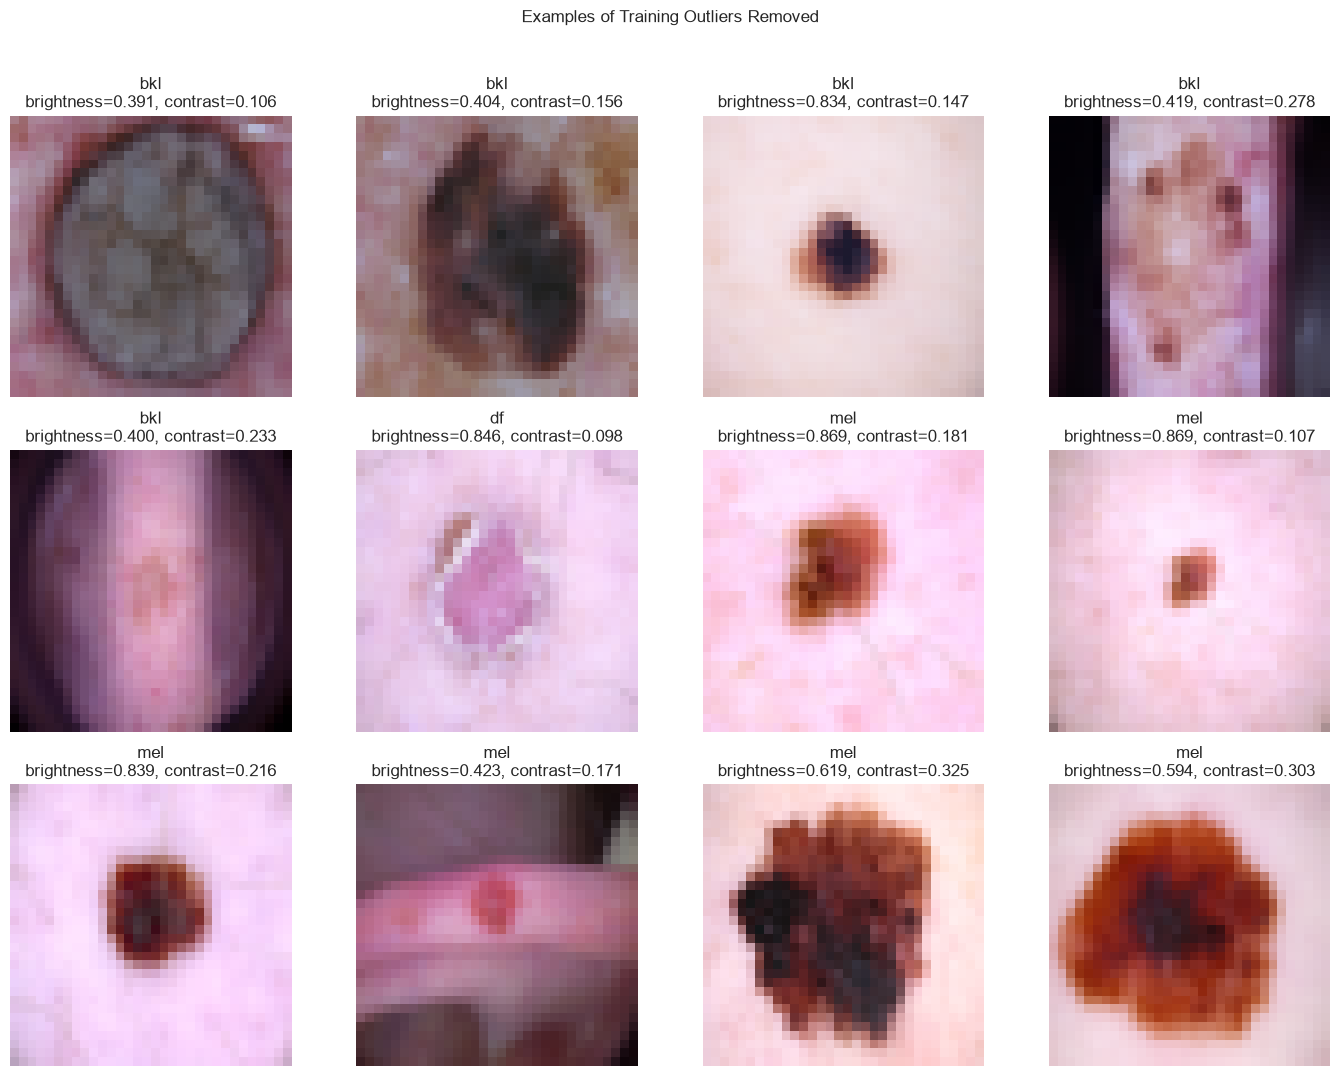

Original training images: 8011
Training outliers removed: 70
Training images remaining: 7941
Validation images unchanged: 1002
Test images unchanged: 1002

Removed images by diagnosis:


,dx,removed_count
0,nv,47
1,mel,17
2,bkl,5
3,df,1


In [16]:
# Display at most 12 examples, but handle every flagged training image.
outlier_indices = np.flatnonzero(train_outlier_mask)
example_indices = outlier_indices[:12]

if len(example_indices) == 0:
    print("No brightness or contrast outliers were flagged.")
else:
    columns = 4
    rows = int(np.ceil(len(example_indices) / columns))
    plt.figure(figsize=(14, 3.5 * rows))

    for plot_number, training_index in enumerate(example_indices, start=1):
        plt.subplot(rows, columns, plot_number)
        plt.imshow(X_train[training_index])
        plt.title(
            f"{class_names[int(y_train[training_index])]}\n"
            f"brightness={train_brightness[training_index]:.3f}, "
            f"contrast={train_contrast[training_index]:.3f}"
        )
        plt.axis("off")

    plt.suptitle("Examples of Training Outliers Removed", y=1.02)
    plt.tight_layout()
    plt.show()

TRAIN_SIZE_BEFORE_OUTLIERS = len(X_train)
OUTLIERS_REMOVED = int(train_outlier_mask.sum())
keep_training_rows = ~train_outlier_mask

removed_outliers_df = train_quality_df.loc[
    train_outlier_mask,
    ["training_row", "image_id", "lesion_id", "dx", "brightness", "contrast"],
].copy()

# Apply the same mask to images, labels, and aligned training metadata.
X_train = X_train[keep_training_rows].copy()
y_train = y_train[keep_training_rows].copy()
train_df = train_metadata_aligned.loc[keep_training_rows].reset_index(drop=True)

assert len(X_train) == len(y_train) == len(train_df)
assert set(np.unique(y_train)) == set(np.arange(len(class_names)))

print("Original training images:", TRAIN_SIZE_BEFORE_OUTLIERS)
print("Training outliers removed:", OUTLIERS_REMOVED)
print("Training images remaining:", len(X_train))
print("Validation images unchanged:", len(X_val))
print("Test images unchanged:", len(X_test))

print("\nRemoved images by diagnosis:")
display(
    removed_outliers_df["dx"]
    .value_counts()
    .rename_axis("dx")
    .reset_index(name="removed_count")
)

In [17]:
removed_ids = set(removed_outliers_df["image_id"])
remaining_ids = set(train_df["image_id"])

overlap = removed_ids & remaining_ids

print("Removed image IDs:", len(removed_ids))
print("Removed IDs still in training data:", len(overlap))

assert len(overlap) == 0

print("All flagged outliers were removed successfully.")

Removed image IDs: 70
Removed IDs still in training data: 0
All flagged outliers were removed successfully.


In [18]:
# 6. Handle Class Imbalance

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.329880043620502, 1: 2.7601668404588113, 2: 1.2979731938542007, 3: 12.466248037676609, 4: 1.2994599901816397, 5: 0.21339890357949048, 6: 9.951127819548873}


## Training Models Part

In [19]:
ALL_LABELS = np.arange(len(class_names))
def evaluate_part2_model(model, model_name, X_eval, y_eval):
    predictions = model.predict(X_eval)
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "Macro Precision": precision_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
    }

    print(f"\n{model_name}")
    print("=" * len(model_name))
    for metric, value in result.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_eval,
        predictions,
        labels=ALL_LABELS,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_eval, predictions, labels=ALL_LABELS)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return result, predictions

In [20]:
# Dataframe process for Logistic Regression and Random Forest models
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)
print(X_val_flat.shape)
print(X_test_flat.shape)

(7941, 3072)
(1002, 3072)
(1002, 3072)


## Majority Class Baseline

Majority class: nv

Majority Class Baseline
Accuracy: 0.6697
Balanced Accuracy: 0.1429
Macro Precision: 0.0957
Macro Recall: 0.1429
Macro F1: 0.1146

Classification Report:
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        32
         bcc     0.0000    0.0000    0.0000        51
         bkl     0.0000    0.0000    0.0000       110
          df     0.0000    0.0000    0.0000        12
         mel     0.0000    0.0000    0.0000       112
          nv     0.6697    1.0000    0.8022       671
        vasc     0.0000    0.0000    0.0000        14

    accuracy                         0.6697      1002
   macro avg     0.0957    0.1429    0.1146      1002
weighted avg     0.4484    0.6697    0.5372      1002



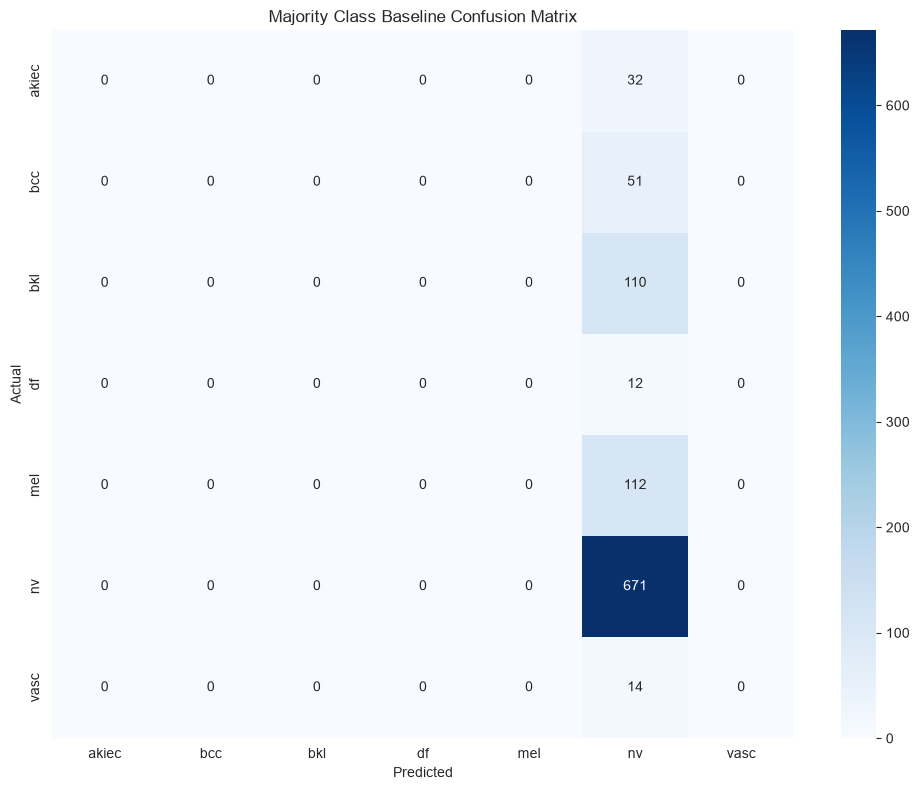

In [21]:
majority_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)
majority_baseline.fit(X_train_flat, y_train)

majority_class_id = int(majority_baseline.predict(X_train_flat[:1])[0])
print("Majority class:", class_names[majority_class_id])

majority_result, majority_predictions = evaluate_part2_model(
    majority_baseline,
    "Majority Class Baseline",
    X_test_flat,
    y_test,
)

## Logistic Regression Model

Training Logistic Regression...

Logistic Regression
Accuracy: 0.5569
Balanced Accuracy: 0.4805
Macro Precision: 0.3285
Macro Recall: 0.4805
Macro F1: 0.3535

Classification Report:
              precision    recall  f1-score   support

       akiec     0.1750    0.2188    0.1944        32
         bcc     0.2985    0.3922    0.3390        51
         bkl     0.3701    0.5182    0.4318       110
          df     0.1136    0.4167    0.1786        12
         mel     0.2554    0.4196    0.3176       112
          nv     0.9174    0.6125    0.7346       671
        vasc     0.1692    0.7857    0.2785        14

    accuracy                         0.5569      1002
   macro avg     0.3285    0.4805    0.3535      1002
weighted avg     0.7080    0.5569    0.6043      1002



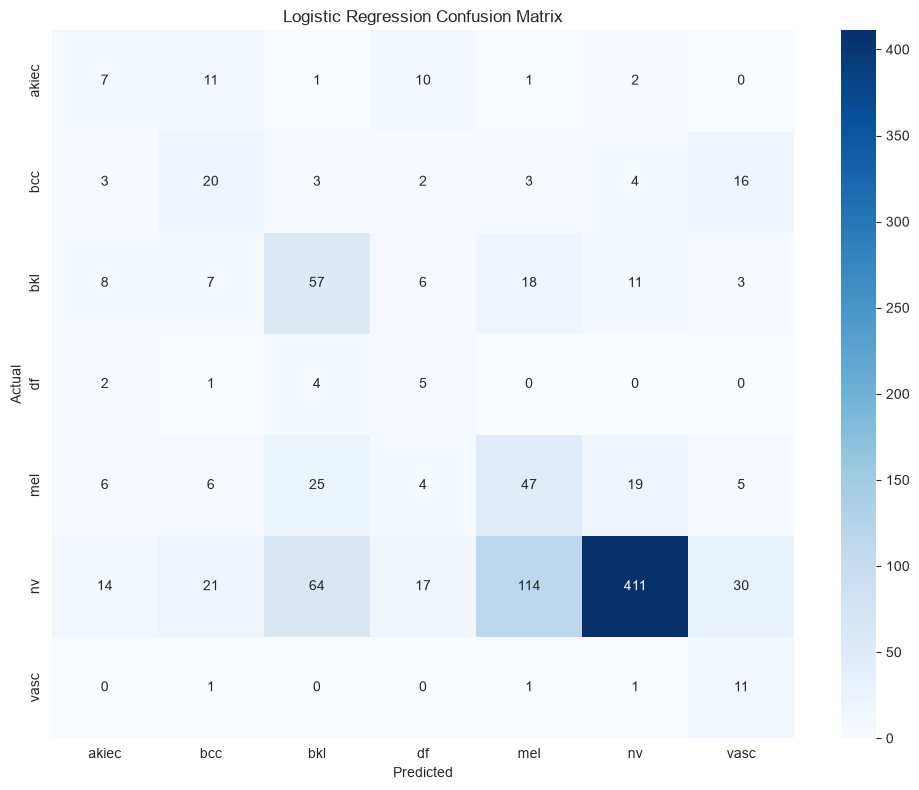

In [22]:
RUN_LOGISTIC_REGRESSION = True

if RUN_LOGISTIC_REGRESSION:
    logistic_model = LogisticRegression(
        solver="saga",
        C=1.0,
        max_iter=500,
        tol=1e-3,
        class_weight=class_weights,
        random_state=42,
    )

    print("Training Logistic Regression...")
    logistic_model.fit(X_train_flat, y_train)

    logistic_result, logistic_predictions = evaluate_part2_model(
        logistic_model,
        "Logistic Regression",
        X_test_flat,
        y_test,
    )
else:
    logistic_model = None
    logistic_result = None
    print("Logistic Regression skipped.")

In [23]:
from sklearn.metrics import log_loss

# Majority Class Baseline Log Loss
majority_probabilities = majority_baseline.predict_proba(X_test_flat)

majority_loss = log_loss(
    y_test,
    majority_probabilities,
    labels=ALL_LABELS
)

# Logistic Regression Log Loss
logistic_probabilities = logistic_model.predict_proba(X_test_flat)

logistic_loss = log_loss(
    y_test,
    logistic_probabilities,
    labels=ALL_LABELS
)

print(f"Majority Class Baseline Log Loss: {majority_loss:.4f}")
print(f"Logistic Regression Log Loss: {logistic_loss:.4f}")

Majority Class Baseline Log Loss: 11.9066
Logistic Regression Log Loss: 1.3619


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Log Loss
0,Majority Class Baseline,0.6697,0.1429,0.0957,0.1429,0.1146,11.9066
1,Logistic Regression,0.5569,0.4805,0.3285,0.4805,0.3535,1.3619


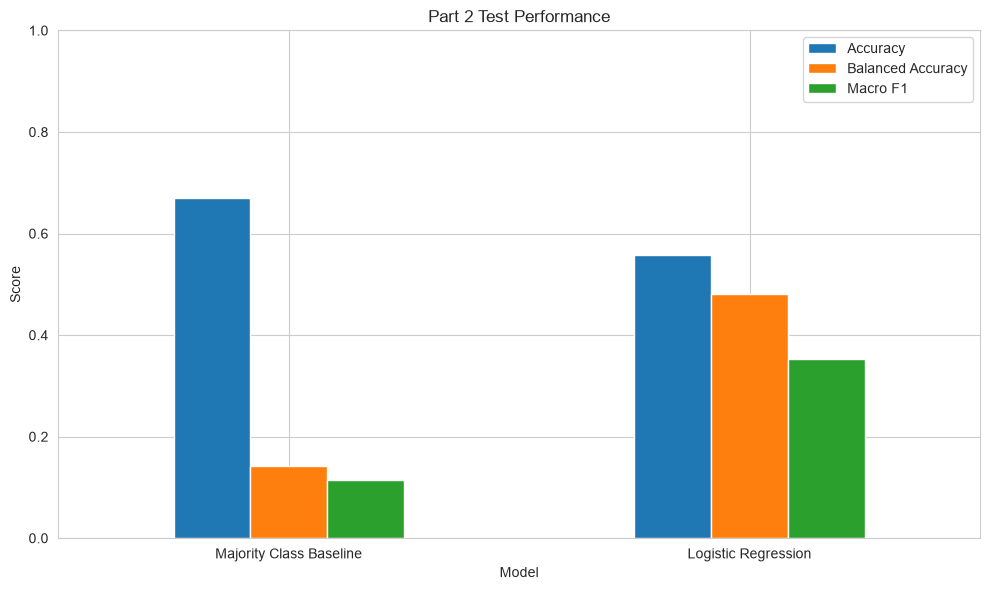

In [24]:
majority_result["Log Loss"] = majority_loss
logistic_result["Log Loss"] = logistic_loss

part2_results_df = pd.DataFrame([
    majority_result,
    logistic_result
])

display(part2_results_df.round(4))

plot_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1"
]

part2_results_df.set_index("Model")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1),
    rot=0
)

plt.title("Part 2 Test Performance")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

## Random Forest Model

In [25]:
# Train Random Forest Classifier

print("Random Forest training shape:", X_train_flat.shape)
print("Random Forest test shape:", X_test_flat.shape)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_flat, y_train)


Random Forest training shape: (7941, 3072)
Random Forest test shape: (1002, 3072)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 4.329880043620502, 1: 2.7601668404588113, 2: 1.2979731938542007, 3: 12.466248037676609, ...}"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number

Random Forest Accuracy: 0.6596806387225549
Random Forest Balanced Accuracy: 0.40507299790258877

Classification Report:
              precision    recall  f1-score   support

       akiec       0.42      0.31      0.36        32
         bcc       0.35      0.55      0.43        51
         bkl       0.42      0.56      0.48       110
          df       0.00      0.00      0.00        12
         mel       0.31      0.44      0.36       112
          nv       0.88      0.76      0.81       671
        vasc       0.38      0.21      0.27        14

    accuracy                           0.66      1002
   macro avg       0.39      0.41      0.39      1002
weighted avg       0.70      0.66      0.67      1002



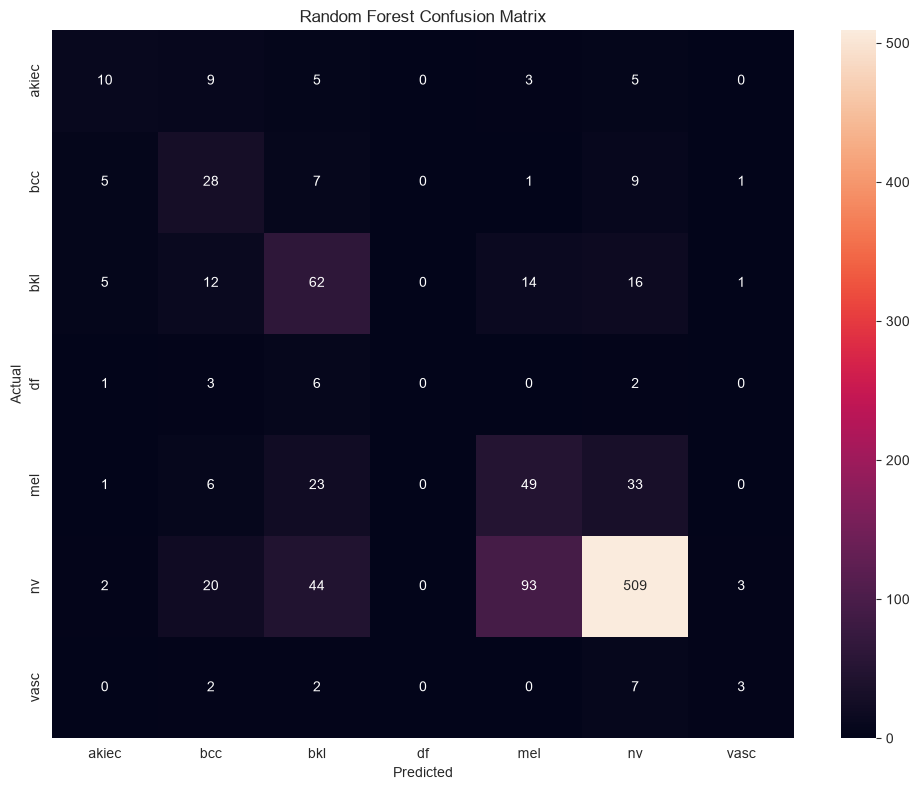

In [26]:
# Evaluate Random Forest Model

rf_predictions = rf_model.predict(X_test_flat)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Random Forest Balanced Accuracy:", balanced_accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, rf_predictions, labels=np.arange(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LSTM Model

In [31]:
# Train LSTM Classifier


import tensorflow as tf

tf.random.set_seed(42)

# Treat image rows as sequence steps; width × channels are features.
X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
X_val_lstm = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(len(class_names), activation="softmax"),
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    verbose=1,
)

test_loss, test_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)
print("LSTM test loss:", test_loss)
print("LSTM test accuracy:", test_accuracy)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2030 - loss: 1.9556 - val_accuracy: 0.2415 - val_loss: 1.9169
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4076 - loss: 1.8965 - val_accuracy: 0.4451 - val_loss: 1.7877
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4017 - loss: 1.8612 - val_accuracy: 0.4930 - val_loss: 1.5253
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3231 - loss: 1.8316 - val_accuracy: 0.5080 - val_loss: 1.5565
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4011 - loss: 1.7703 - val_accuracy: 0.5230 - val_loss: 1.3702
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4313 - loss: 1.7273 - val_accuracy: 0.4611 - val_loss: 1.4344
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4605 - loss: 1.6850 - val_accuracy: 0.4691 - val_loss: 1.4533
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4648 - loss: 1.6712 - val_